In [3]:
import os
import sys
import subprocess

# --- Step 0: Check if we're *already* inside any ml-fastvit subfolder ---
if "ml-fastvit" in os.getcwd().split(os.sep):
    print(f"⚠️ You're already inside an 'ml-fastvit' folder → {os.getcwd()}")
    print("🛑 Skipping clone + cd to avoid nesting.")
else:
    # --- Step 1: Clone repo if not present ---
    if not os.path.exists("ml-fastvit"):
        !git clone https://github.com/apple/ml-fastvit.git
        print("✅ Cloned ml-fastvit")
    else:
        print("ℹ️ ml-fastvit repo already exists")

    # --- Step 2: Move into the repo directory ---
    os.chdir("ml-fastvit")
    print(f"📂 Changed directory to: {os.getcwd()}")

    # --- Step 3: Install requirements ---
    subprocess.call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])

    # --- Step 4: Create checkpoints folder if missing ---
    os.makedirs("checkpoints", exist_ok=True)
    print("✅ Setup complete. \n ***YOU ARE NOW IN THE /Users/williambu/RESEARCH/ml-fastvit directory")
    
import torch
from timm.models import create_model
from models.modules.mobileone import reparameterize_model

# Step 1: Create the FastViT-sa12 model architecture
model = create_model("fastvit_sa12")

# Step 2: Load the .pth.tar checkpoint
checkpoint = torch.load("fastvit_sa12.pth.tar", map_location="cpu")
model.load_state_dict(checkpoint["state_dict"])

# Step 3: Reparameterize the model for inference
model.eval()
model_inf = reparameterize_model(model)

print("✅ FastViT-sa12 loaded and reparameterized for inference.")


ablation_data_processing.ipynb
ablation1_train.ipynb
ablation2_datapartitions.ipynb
ablation2_train.ipynb
classifier_dataset
CLASSIFIER_DATASET_PREPROCCESSING.ipynb
COLAB_VERSION.ipynb
COLABTOJUPYTER.py
DATASET
dataset_paritition_training.ipynb
dataset_partitions.ipynb
fastvit_finetuned_ablation1.pth
fastvit_finetuned_ablation2.pth
fastvit_finetuned_classifier_trial3_60_15_25.pth
FASTVIT_MLP.ipynb
ml-fastvit
ml-fastvlm
mobilesam_dataset_gen.ipynb
output
processed_data
rf_detr.ipynb
rf-detr-nano.pth
Training_Final-Copy1.ipynb
Training_Final.ipynb
unified_pipeline.ipynb
Untitled.ipynb
weights
ℹ️ ml-fastvit repo already exists
📂 Changed directory to: /Users/williambu/RESEARCH/ml-fastvit
✅ Setup complete. 
 ***YOU ARE NOW IN THE /Users/williambu/RESEARCH/ml-fastvit directory


/opt/anaconda3/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/anaconda3/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Users/williambu/RESEARCH/ml-fastvit/models/fastvit.py:956: UserWarning: Overwriting fastvit_t8 in registry with models.fastvit.fastvit_t8. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/Users/williambu/RESEARCH/ml-fastvit/models/fastvit.py:978: UserWarning: Overwriting fastvit_t12 in registry with models.fastvit.fastvit_t12. This is because the name being regi

If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first
✅ FastViT-sa12 loaded and reparameterized for inference.


In [39]:
# newest code with fastvit fine tuning as well - Updated for new folder structure
'''
After (Fine-tuning):

FastViT weights update during training
Both FastViT and MLP learn together
FastViT switches between .train() and .eval()
Gradients flow through entire network
'''

import os
import torch
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from timm.models import create_model
import numpy as np

# === CONFIG ===
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 15  
NUM_CLASSES = 5
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Fine-tuning specific parameters
FEATURE_LEARNING_RATE = 1e-5  # Lower LR for pre-trained backbone
MLP_LEARNING_RATE = 1e-3      # Higher LR for random MLP

# === TRANSFORMS ===
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# === CUSTOM DATASET CLASS TO SKIP HIDDEN FILES ===
class FilteredImageFolder(ImageFolder):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.samples = [(path, class_idx) for path, class_idx in self.samples 
                       if not os.path.basename(path).startswith('.') and 
                       not os.path.basename(path).startswith('_')]
        print(f"Filtered dataset: {len(self.samples)} valid images found")

# === LOAD DATASETS FROM NEW FOLDER STRUCTURE ===
base_data_dir = "/Volumes/external/Research_ssd/trial3/ablation2_splits/75_15_10"
train_data_dir = os.path.join(base_data_dir, "training")
val_data_dir = os.path.join(base_data_dir, "validation")

# Load training and validation datasets
train_dataset = FilteredImageFolder(root=train_data_dir, transform=transform)
val_dataset = FilteredImageFolder(root=val_data_dir, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Detected classes:", train_dataset.classes)
print("Class to index mapping:", train_dataset.class_to_idx)
print(f"Training: {len(train_dataset)} samples, Validation: {len(val_dataset)} samples")

# Verify class consistency between train and validation
assert train_dataset.classes == val_dataset.classes, "Class mismatch between train and validation datasets!"
assert train_dataset.class_to_idx == val_dataset.class_to_idx, "Class index mismatch between train and validation datasets!"

# === LOAD FASTVIT MODEL ===
print("Loading FastViT-SA12 model...")
model = create_model("fastvit_sa12", pretrained=False).to(DEVICE)

# Load your custom checkpoint
checkpoint_path = "fastvit_sa12.pth.tar"
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    
    # Handle different checkpoint formats
    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif "model" in checkpoint:
        state_dict = checkpoint["model"]
    else:
        state_dict = checkpoint
    
    # Remove 'module.' prefix if present (from DataParallel)
    if list(state_dict.keys())[0].startswith('module.'):
        state_dict = {k[7:]: v for k, v in state_dict.items()}
    
    model.load_state_dict(state_dict, strict=False)
    print("Checkpoint loaded successfully")
else:
    print(f"WARNING: Checkpoint {checkpoint_path} not found!")
    print("Using randomly initialized model - this may not work well!")

# Remove the original classification head
if hasattr(model, 'head'):
    original_head_dim = model.head.in_features
    model.head = nn.Identity()  # Remove classification head permanently
elif hasattr(model, 'classifier'):
    original_head_dim = model.classifier.in_features
    model.classifier = nn.Identity()
else:
    # Determine feature dimension
    with torch.no_grad():
        dummy_input = torch.randn(1, 3, *IMG_SIZE).to(DEVICE)
        dummy_features = model(dummy_input)
        if isinstance(dummy_features, tuple):
            dummy_features = dummy_features[0]
        if len(dummy_features.shape) == 4:
            dummy_features = torch.mean(dummy_features, dim=[2, 3])
        original_head_dim = dummy_features.shape[1]

print(f"Feature dimension: {original_head_dim}")

# === MLP CLASSIFIER ===
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=NUM_CLASSES):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(x)

mlp = MLPClassifier(original_head_dim).to(DEVICE)


backbone_optimizer = torch.optim.Adam(model.parameters(), lr=FEATURE_LEARNING_RATE)
mlp_optimizer = torch.optim.Adam(mlp.parameters(), lr=MLP_LEARNING_RATE)

criterion = nn.CrossEntropyLoss()

print(f"FastViT learning rate: {FEATURE_LEARNING_RATE}")
print(f"MLP learning rate: {MLP_LEARNING_RATE}")
print(f"Training on device: {DEVICE}")


def validate_model():
    model.eval()
    mlp.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            
            # Extract features (now trainable features!)
            features = model(imgs)
            if isinstance(features, tuple):
                features = features[0]
            if len(features.shape) == 4:
                features = torch.mean(features, dim=[2, 3])
            if len(features.shape) > 2:
                features = features.view(features.size(0), -1)
            
            preds = mlp(features)
            loss = criterion(preds, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(preds.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return val_loss / len(val_loader), 100 * correct / total

# === TRAINING LOOP WITH FINE-TUNING ===
print("\nStarting fine-tuning...")
print("=" * 50)

# Track best validation accuracy
best_val_accuracy = 0.0
best_epoch = 0

for epoch in range(EPOCHS):
    # TRAINING PHASE
    model.train()  # CRITICAL: Model is now trainable!
    mlp.train()
    
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (imgs, labels) in enumerate(train_loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        
        # Clear gradients for both optimizers
        backbone_optimizer.zero_grad()
        mlp_optimizer.zero_grad()
        
        # Forward pass - NO torch.no_grad()!
        features = model(imgs)  # Gradients will flow through FastViT
        
        # Handle different feature formats
        if isinstance(features, tuple):
            features = features[0]
        if len(features.shape) == 4:
            features = torch.mean(features, dim=[2, 3])
        if len(features.shape) > 2:
            features = features.view(features.size(0), -1)
        
        # MLP forward pass
        preds = mlp(features)
        loss = criterion(preds, labels)
        
        # Backward pass - updates BOTH FastViT AND MLP
        loss.backward()
        
        # Update both optimizers
        backbone_optimizer.step()
        mlp_optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = torch.max(preds.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Batch {batch_idx}, Loss: {loss.item():.4f}")
    
    # Calculate metrics
    train_loss = total_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    val_loss, val_accuracy = validate_model()
    
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train - Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.2f}%")
    print(f"  Val   - Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.2f}%")
    
    # Save best model based on validation accuracy
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        
        # Save the best model
        torch.save({
            'fastvit_state_dict': model.state_dict(),
            'mlp_state_dict': mlp.state_dict(),
            'feature_dim': original_head_dim,
            'num_classes': NUM_CLASSES,
            'epoch': epoch + 1,
            'best_val_accuracy': best_val_accuracy,
            'classes': train_dataset.classes,
            'backbone_lr': FEATURE_LEARNING_RATE,
            'mlp_lr': MLP_LEARNING_RATE
        }, 'fastvit_finetuned_classifier_trial3_abl2_75_15_10.pth')
        
        print(f"  *** New best validation accuracy: {best_val_accuracy:.2f}% - Model saved! ***")
    
    print("-" * 30)

print("Fine-tuning completed!")
print(f"Best validation accuracy: {best_val_accuracy:.2f}% at epoch {best_epoch}")
print("Fine-tuned models saved:")
print(f"  • Best model (Val Acc: {best_val_accuracy:.2f}%): 'fastvit_finetuned_classifier_trial3_abl2_75_15_10.pth'")

Filtered dataset: 1575 valid images found
Filtered dataset: 315 valid images found
Detected classes: ['chlorosis', 'dirt', 'necrosis', 'residue', 'water']
Class to index mapping: {'chlorosis': 0, 'dirt': 1, 'necrosis': 2, 'residue': 3, 'water': 4}
Training: 1575 samples, Validation: 315 samples
Loading FastViT-SA12 model...
Loading checkpoint from fastvit_sa12.pth.tar
Checkpoint loaded successfully
Feature dimension: 1024
FastViT learning rate: 1e-05
MLP learning rate: 0.001
Training on device: mps

Starting fine-tuning...
Epoch 1/15, Batch 0, Loss: 1.5523
Epoch 1/15, Batch 10, Loss: 1.6544
Epoch 1/15, Batch 20, Loss: 1.5772
Epoch 1/15, Batch 30, Loss: 1.4250
Epoch 1/15, Batch 40, Loss: 1.4072
Epoch 1/15, Batch 50, Loss: 1.2682
Epoch 1/15, Batch 60, Loss: 0.9949
Epoch 1/15, Batch 70, Loss: 1.1288
Epoch 1/15, Batch 80, Loss: 1.2016
Epoch 1/15, Batch 90, Loss: 0.8301
Epoch 1/15, Batch 100, Loss: 0.8447
Epoch 1/15, Batch 110, Loss: 0.2292
Epoch 1/15, Batch 120, Loss: 0.5934
Epoch 1/15, Ba

FastViT Fine-tuned Model Testing
Device: mps
Filtered dataset: 210 valid images found
Test dataset loaded: 210 samples
Classes: ['chlorosis', 'dirt', 'necrosis', 'residue', 'water']
Loading model from: fastvit_finetuned_classifier_trial3_abl2_75_15_10.pth
Model info:
  - Trained for 9 epochs
  - Best validation accuracy: 99.37%
  - Feature dimension: 1024
  - Classes: ['chlorosis', 'dirt', 'necrosis', 'residue', 'water']
Model and MLP loaded successfully!

Running model evaluation on test set...
  Processed batch 1/27
  Processed batch 6/27
  Processed batch 11/27
  Processed batch 16/27
  Processed batch 21/27
  Processed batch 26/27

OVERALL TEST RESULTS
Test Accuracy: 99.52%
Total samples: 210
Correctly classified: 209

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   chlorosis      1.000     0.976     0.988        42
        dirt      1.000     1.000     1.000        42
    necrosis      0.977     1.000     0.988        42
     residue      1

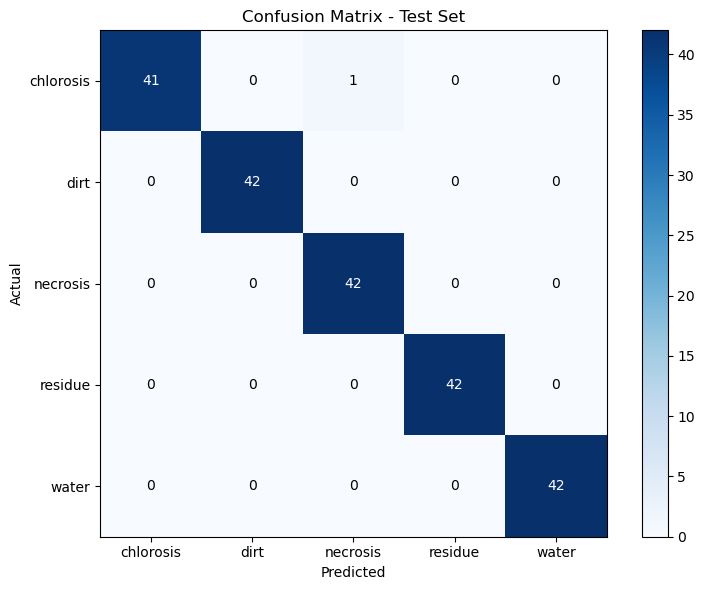


TESTING COMPLETED!


In [41]:
import os
import torch
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from timm.models import create_model
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


# === CONFIG ===
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Model checkpoint path
MODEL_PATH = 'fastvit_finetuned_classifier_trial3_abl2_75_15_10.pth'


transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# === CUSTOM DATASET CLASS TO SKIP HIDDEN FILES ===
class FilteredImageFolder(ImageFolder):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.samples = [(path, class_idx) for path, class_idx in self.samples 
                       if not os.path.basename(path).startswith('.') and 
                       not os.path.basename(path).startswith('_')]
        print(f"Filtered dataset: {len(self.samples)} valid images found")


class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=3):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(x)

def load_model_and_mlp(model_path, device):
    """Load the saved FastViT model and MLP classifier"""
    

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model checkpoint not found at: {model_path}")
    

    print(f"Loading model from: {model_path}")
    checkpoint = torch.load(model_path, map_location=device)
    

    feature_dim = checkpoint['feature_dim']
    num_classes = checkpoint['num_classes']
    classes = checkpoint['classes']
    best_val_accuracy = checkpoint['best_val_accuracy']
    epoch = checkpoint['epoch']
    
    print(f"Model info:")
    print(f"  - Trained for {epoch} epochs")
    print(f"  - Best validation accuracy: {best_val_accuracy:.2f}%")
    print(f"  - Feature dimension: {feature_dim}")
    print(f"  - Classes: {classes}")
    

    model = create_model("fastvit_sa12", pretrained=False).to(device)
    
    # Remove the original classification head
    if hasattr(model, 'head'):
        model.head = nn.Identity()
    elif hasattr(model, 'classifier'):
        model.classifier = nn.Identity()
    
    # Load FastViT weights
    model.load_state_dict(checkpoint['fastvit_state_dict'])
    
    # Create and load MLP
    mlp = MLPClassifier(feature_dim, num_classes=num_classes).to(device)
    mlp.load_state_dict(checkpoint['mlp_state_dict'])
    model.eval()
    mlp.eval()
    
    print("Model and MLP loaded successfully!")
    
    return model, mlp, classes

def test_model(model, mlp, test_loader, device, class_names):
    """Test the model and return detailed metrics"""
    
    print("\nRunning model evaluation on test set...")
    
    all_predictions = []
    all_labels = []
    all_probabilities = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(test_loader):
            imgs, labels = imgs.to(device), labels.to(device)
            
            # Extract features
            features = model(imgs)
            if isinstance(features, tuple):
                features = features[0]
            if len(features.shape) == 4:
                features = torch.mean(features, dim=[2, 3])
            if len(features.shape) > 2:
                features = features.view(features.size(0), -1)
            
            # Get predictions
            logits = mlp(features)
            probabilities = torch.softmax(logits, dim=1)
            _, predicted = torch.max(logits, 1)
            
            # Store results
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            
            # Update counters
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            if batch_idx % 5 == 0:
                print(f"  Processed batch {batch_idx+1}/{len(test_loader)}")
    
    # Calculate accuracy
    test_accuracy = 100 * correct / total
    
    return all_predictions, all_labels, all_probabilities, test_accuracy

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot confusion matrix using only matplotlib"""
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix - Test Set')
    plt.colorbar(im)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(range(len(class_names)), class_names)
    plt.yticks(range(len(class_names)), class_names)
    plt.tight_layout()
    plt.show()

def analyze_per_class_performance(y_true, y_pred, probabilities, class_names):
    """Analyze performance for each class"""
    
    print("\n" + "="*60)
    print("PER-CLASS ANALYSIS")
    print("="*60)
    
    for i, class_name in enumerate(class_names):
        # Get indices for this class
        class_indices = [j for j, label in enumerate(y_true) if label == i]
        
        if len(class_indices) == 0:
            continue
        
        # Calculate metrics for this class
        class_predictions = [y_pred[j] for j in class_indices]
        class_probabilities = [probabilities[j][i] for j in class_indices]
        
        correct_predictions = sum(1 for pred in class_predictions if pred == i)
        accuracy = 100 * correct_predictions / len(class_predictions)
        avg_confidence = np.mean(class_probabilities)
        
        print(f"\n{class_name.upper()}:")
        print(f"  Total samples: {len(class_indices)}")
        print(f"  Correctly predicted: {correct_predictions}")
        print(f"  Accuracy: {accuracy:.2f}%")
        print(f"  Average confidence: {avg_confidence:.3f}")
        
        # Find misclassified samples
        misclassified = [class_indices[j] for j, pred in enumerate(class_predictions) if pred != i]
        if misclassified:
            print(f"  Misclassified: {len(misclassified)} samples")
            # Show which classes they were misclassified as
            misclass_as = {}
            for idx in misclassified:
                pred_class = class_names[y_pred[idx]]
                misclass_as[pred_class] = misclass_as.get(pred_class, 0) + 1
            for pred_class, count in misclass_as.items():
                print(f"    - {count} misclassified as {pred_class}")

def main():
    """Main testing function"""
    
    print("FastViT Fine-tuned Model Testing")
    print("=" * 50)
    print(f"Device: {DEVICE}")
    
    # Load test dataset
    test_data_dir = "/Volumes/external/Research_ssd/trial3/ablation2_splits/75_15_10/test"
    
    if not os.path.exists(test_data_dir):
        raise FileNotFoundError(f"Test data directory not found: {test_data_dir}")
    
    test_dataset = FilteredImageFolder(root=test_data_dir, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print(f"Test dataset loaded: {len(test_dataset)} samples")
    print(f"Classes: {test_dataset.classes}")
    
    # Load model
    model, mlp, saved_classes = load_model_and_mlp(MODEL_PATH, DEVICE)
    
    # Verify class consistency
    if test_dataset.classes != saved_classes:
        print("WARNING: Class mismatch between test data and saved model!")
        print(f"Test classes: {test_dataset.classes}")
        print(f"Model classes: {saved_classes}")
    
    # Run testing
    predictions, labels, probabilities, test_accuracy = test_model(
        model, mlp, test_loader, DEVICE, test_dataset.classes
    )
    
    # Print overall results
    print("\n" + "="*60)
    print("OVERALL TEST RESULTS")
    print("="*60)
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Total samples: {len(labels)}")
    print(f"Correctly classified: {sum(1 for p, l in zip(predictions, labels) if p == l)}")
    
    # Detailed classification report
    print("\n" + "="*60)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(labels, predictions, target_names=test_dataset.classes, digits=3))
    
    # Per-class analysis
    analyze_per_class_performance(labels, predictions, probabilities, test_dataset.classes)
    
    # Plot confusion matrix
    print("\nGenerating confusion matrix...")
    plot_confusion_matrix(labels, predictions, test_dataset.classes)
    
    print("\n" + "="*60)
    print("TESTING COMPLETED!")
    print("="*60)

if __name__ == "__main__":
    main()

FastViT Model - Visual Analysis
Found 315 images across 5 classes
Loading model...
Model loaded. Classes: ['chlorosis', 'dirt', 'necrosis', 'residue', 'water']
Analyzing all test images...
  Processed 20/315 images
  Processed 40/315 images
  Processed 60/315 images
  Processed 80/315 images
  Processed 100/315 images
  Processed 120/315 images
  Processed 140/315 images
  Processed 160/315 images
  Processed 180/315 images
  Processed 200/315 images
  Processed 220/315 images
  Processed 240/315 images
  Processed 260/315 images
  Processed 280/315 images
  Processed 300/315 images

ANALYSIS SUMMARY
Total images: 315
Correctly classified: 312
Misclassified: 3
  chlorosis: 62 correct
  dirt: 63 correct
  necrosis: 62 correct
  residue: 63 correct
  water: 62 correct

Generating visualizations...


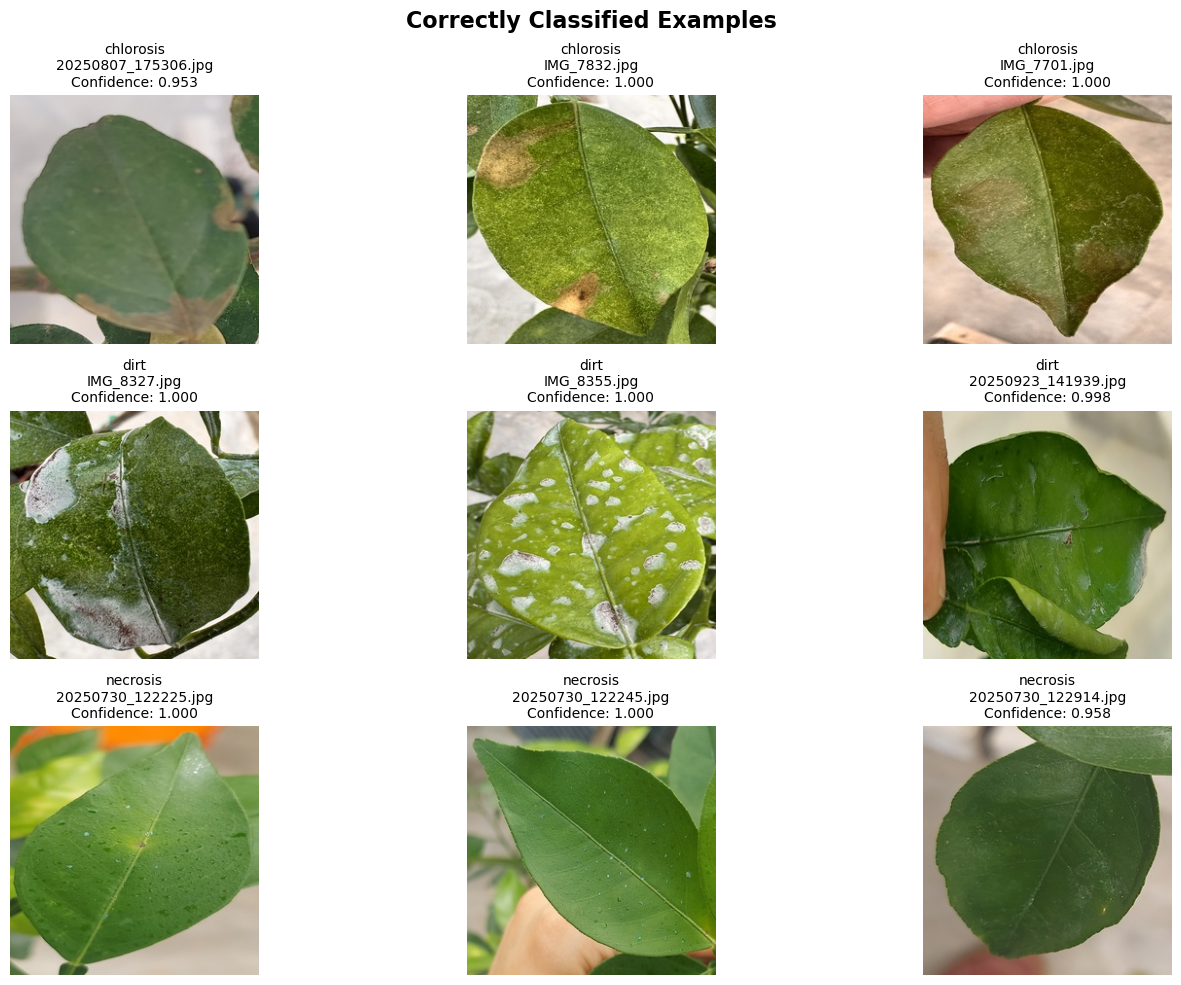

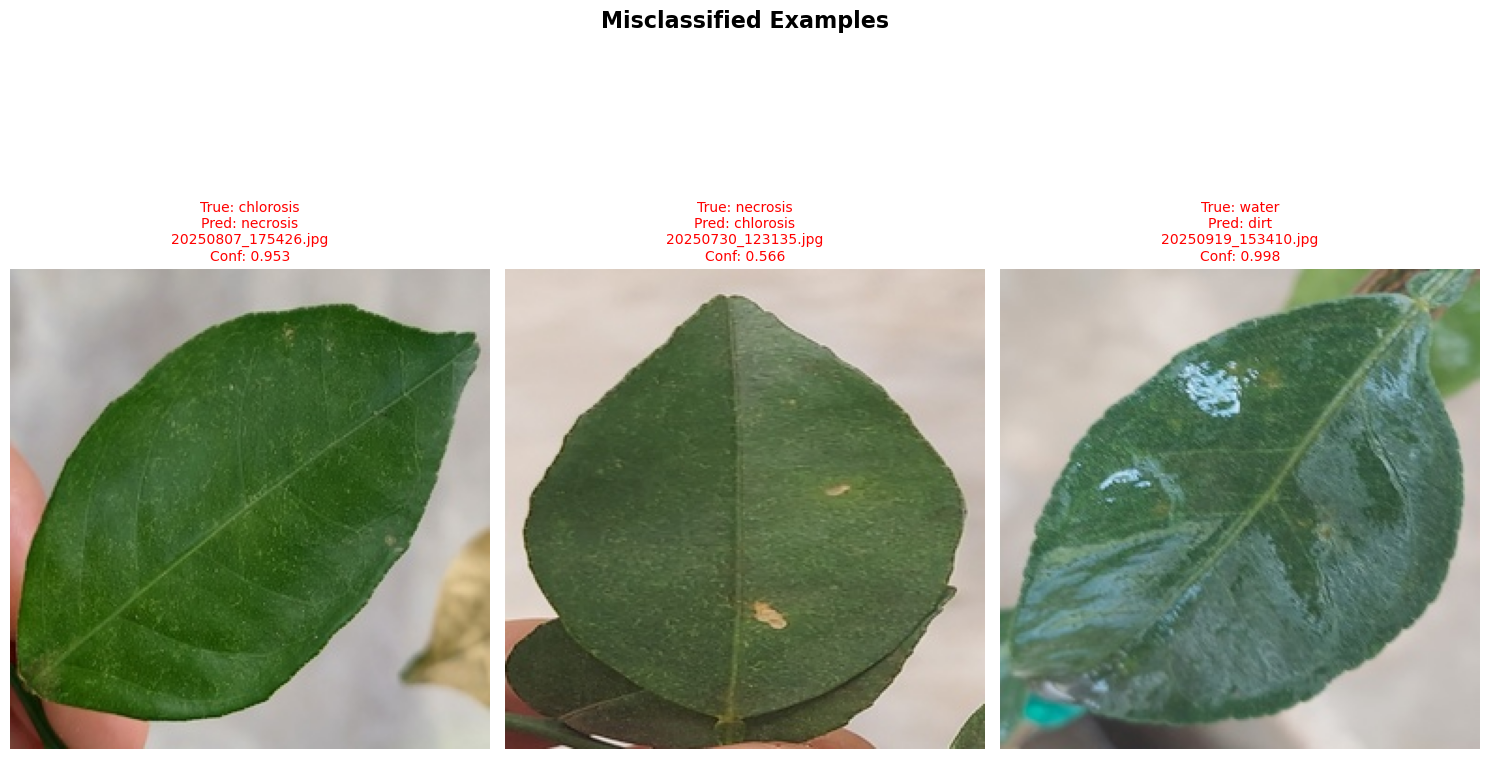


MISCLASSIFIED EXAMPLES - DETAILED ANALYSIS

Misclassified Example 1:
  File: 20250807_175426.jpg
  True class: chlorosis
  Predicted class: necrosis
  Prediction confidence: 0.953
  All class probabilities:
    chlorosis: 0.047 ← TRUE
    dirt: 0.000
    necrosis: 0.953 ← PRED
    residue: 0.000
    water: 0.000

Misclassified Example 2:
  File: 20250730_123135.jpg
  True class: necrosis
  Predicted class: chlorosis
  Prediction confidence: 0.566
  All class probabilities:
    chlorosis: 0.566 ← PRED
    dirt: 0.000
    necrosis: 0.434 ← TRUE
    residue: 0.000
    water: 0.000

Misclassified Example 3:
  File: 20250919_153410.jpg
  True class: water
  Predicted class: dirt
  Prediction confidence: 0.998
  All class probabilities:
    chlorosis: 0.000
    dirt: 0.998 ← PRED
    necrosis: 0.000
    residue: 0.000
    water: 0.002 ← TRUE

VISUAL ANALYSIS COMPLETED!


In [32]:
import os
import torch
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from timm.models import create_model
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random

# === CONFIG ===
IMG_SIZE = (256, 256)
BATCH_SIZE = 1  # Process one image at a time for visualization
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Model checkpoint path
MODEL_PATH = '' #path to the fastvit model weights

# === TRANSFORMS ===
# Transform for model inference (same as training)
model_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transform for display (no normalization)
display_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE)
])

# === CUSTOM DATASET FOR VISUALIZATION ===
class VisualizationDataset:
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.samples = []
        self.class_to_idx = {}
        self.classes = []
        
        # Get class names
        for class_name in sorted(os.listdir(root_dir)):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.classes.append(class_name)
                self.class_to_idx[class_name] = len(self.classes) - 1
        
        # Get all image paths
        for class_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(root_dir, class_name)
            for filename in os.listdir(class_path):
                if not filename.startswith('.') and not filename.startswith('_'):
                    filepath = os.path.join(class_path, filename)
                    if filepath.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')):
                        self.samples.append((filepath, class_idx))
        
        print(f"Found {len(self.samples)} images across {len(self.classes)} classes")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        
        # Load image for model
        image = Image.open(filepath).convert('RGB')
        model_image = model_transform(image)
        
        # Load image for display
        display_image = display_transform(image)
        
        return model_image, display_image, label, filepath

# === MLP CLASSIFIER ===
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=3):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(x)

def load_model_and_mlp(model_path, device):
    """Load the saved FastViT model and MLP classifier"""
    
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    feature_dim = checkpoint['feature_dim']
    num_classes = checkpoint['num_classes']
    classes = checkpoint['classes']
    
    # Load FastViT model
    model = create_model("fastvit_sa12", pretrained=False).to(device)
    
    # Remove the original classification head
    if hasattr(model, 'head'):
        model.head = nn.Identity()
    elif hasattr(model, 'classifier'):
        model.classifier = nn.Identity()
    
    # Load weights
    model.load_state_dict(checkpoint['fastvit_state_dict'])
    
    # Create and load MLP
    mlp = MLPClassifier(feature_dim, num_classes=num_classes).to(device)
    mlp.load_state_dict(checkpoint['mlp_state_dict'])
    
    # Set to evaluation mode
    model.eval()
    mlp.eval()
    
    return model, mlp, classes

def predict_single_image(model, mlp, image_tensor, device):
    """Get prediction for a single image"""
    
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)  # Add batch dimension
        
        # Extract features
        features = model(image_tensor)
        if isinstance(features, tuple):
            features = features[0]
        if len(features.shape) == 4:
            features = torch.mean(features, dim=[2, 3])
        if len(features.shape) > 2:
            features = features.view(features.size(0), -1)
        
        # Get predictions
        logits = mlp(features)
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(logits, dim=1).item()
        confidence = probabilities[0][predicted_class].item()
        
        return predicted_class, confidence, probabilities[0].cpu().numpy()

def analyze_test_predictions(model, mlp, dataset, class_names, device):
    """Analyze all test predictions and categorize them"""
    
    correct_examples = {class_name: [] for class_name in class_names}
    misclassified_examples = []
    
    print("Analyzing all test images...")
    
    for idx in range(len(dataset)):
        model_image, display_image, true_label, filepath = dataset[idx]
        
        # Get prediction
        pred_label, confidence, all_probs = predict_single_image(model, mlp, model_image, device)
        
        # Store example
        example = {
            'filepath': filepath,
            'display_image': display_image,
            'true_label': true_label,
            'true_class': class_names[true_label],
            'pred_label': pred_label,
            'pred_class': class_names[pred_label],
            'confidence': confidence,
            'all_probabilities': all_probs
        }
        
        if pred_label == true_label:
            correct_examples[class_names[true_label]].append(example)
        else:
            misclassified_examples.append(example)
        
        if (idx + 1) % 20 == 0:
            print(f"  Processed {idx + 1}/{len(dataset)} images")
    
    return correct_examples, misclassified_examples

def plot_image_grid(examples, title, max_per_class=3, figsize=(15, 10)):
    """Plot a grid of example images"""
    
    if not examples:
        print(f"No examples found for: {title}")
        return
    
    # Calculate grid size
    if isinstance(examples, dict):  # Correct examples by class
        total_images = min(sum(min(len(class_examples), max_per_class) for class_examples in examples.values()), 9)
        cols = 3
        rows = (total_images + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        axes = np.array(axes).reshape(rows, cols)  # Ensure 2D array
        
        plot_idx = 0
        for class_name, class_examples in examples.items():
            for i, example in enumerate(class_examples[:max_per_class]):
                if plot_idx >= total_images:
                    break
                    
                row = plot_idx // cols
                col = plot_idx % cols
                
                # Plot image
                axes[row, col].imshow(example['display_image'])
                axes[row, col].axis('off')
                
                # Title with prediction info
                filename = os.path.basename(example['filepath'])
                axes[row, col].set_title(
                    f"{example['true_class']}\n"
                    f"{filename}\n"
                    f"Confidence: {example['confidence']:.3f}",
                    fontsize=10
                )
                
                plot_idx += 1
        
        # Hide empty subplots
        for i in range(plot_idx, rows * cols):
            row = i // cols
            col = i % cols
            axes[row, col].axis('off')
    
    else:  # Misclassified examples
        total_images = min(len(examples), 6)
        cols = 3
        rows = (total_images + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        axes = np.array(axes).reshape(rows, cols)  # Ensure 2D array
        
        for i, example in enumerate(examples[:total_images]):
            row = i // cols
            col = i % cols
            ax = axes[row, col]
            
            # Plot image
            ax.imshow(example['display_image'])
            ax.axis('off')
            
            # Title with error info
            filename = os.path.basename(example['filepath'])
            ax.set_title(
                f"True: {example['true_class']}\n"
                f"Pred: {example['pred_class']}\n"
                f"{filename}\n"
                f"Conf: {example['confidence']:.3f}",
                fontsize=10,
                color='red'
            )
        
        # Hide empty subplots
        for i in range(total_images, rows * cols):
            row = i // cols
            col = i % cols
            axes[row, col].axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def show_probability_distributions(misclassified_examples, class_names):
    """Show probability distributions for misclassified examples"""
    
    if not misclassified_examples:
        print("No misclassified examples to analyze!")
        return
    
    print("\n" + "="*60)
    print("MISCLASSIFIED EXAMPLES - DETAILED ANALYSIS")
    print("="*60)
    
    for i, example in enumerate(misclassified_examples):
        print(f"\nMisclassified Example {i+1}:")
        print(f"  File: {os.path.basename(example['filepath'])}")
        print(f"  True class: {example['true_class']}")
        print(f"  Predicted class: {example['pred_class']}")
        print(f"  Prediction confidence: {example['confidence']:.3f}")
        print("  All class probabilities:")
        
        for j, (class_name, prob) in enumerate(zip(class_names, example['all_probabilities'])):
            marker = " ← TRUE" if j == example['true_label'] else " ← PRED" if j == example['pred_label'] else ""
            print(f"    {class_name}: {prob:.3f}{marker}")

def main():
    """Main visualization function"""
    
    print("FastViT Model - Visual Analysis")
    print("=" * 50)
    
    # Load test dataset
    test_data_dir = "" #path to test dataset
    dataset = VisualizationDataset(test_data_dir)
    
    # Load model
    print("Loading model...")
    model, mlp, class_names = load_model_and_mlp(MODEL_PATH, DEVICE)
    print(f"Model loaded. Classes: {class_names}")
    
    # Analyze predictions
    correct_examples, misclassified_examples = analyze_test_predictions(
        model, mlp, dataset, class_names, DEVICE
    )
    
    # Print summary
    print(f"\n" + "="*50)
    print("ANALYSIS SUMMARY")
    print("="*50)
    print(f"Total images: {len(dataset)}")
    print(f"Correctly classified: {sum(len(examples) for examples in correct_examples.values())}")
    print(f"Misclassified: {len(misclassified_examples)}")
    
    for class_name, examples in correct_examples.items():
        print(f"  {class_name}: {len(examples)} correct")
    
    # Show visualizations
    print("\nGenerating visualizations...")
    
    # Show correct examples (3 per class)
    plot_image_grid(correct_examples, "Correctly Classified Examples", max_per_class=3)
    
    # Show misclassified examples
    if misclassified_examples:
        plot_image_grid(misclassified_examples, "Misclassified Examples")
        show_probability_distributions(misclassified_examples, class_names)
    else:
        print("NO MISCLASSIFIED EXAMPLES Perfect classification")
    

    print("\nVISUAL ANALYSIS COMPLETED")


if __name__ == "__main__":
    main()